In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [3]:
df = pd.read_csv('cement_slump.csv')

In [4]:
df.sample(5)

,Cement,Slag,Fly ash,Water,SP,Coarse Aggr.,Fine Aggr.,SLUMP(cm),FLOW(cm),Compressive Strength (28-day)(Mpa)
61,288.0,0.0,121.0,177.0,7.0,908.0,829.0,22.5,48.5,39.93
56,307.0,110.0,0.0,189.0,10.0,904.0,765.0,22.0,40.0,31.50
53,309.0,0.0,142.0,218.0,10.0,912.0,680.0,24.0,62.0,38.59
101,297.1,40.9,239.9,194.0,7.5,908.9,651.8,27.5,67.0,49.17
62,299.0,107.0,0.0,210.0,10.0,881.0,745.0,25.0,63.0,28.29


In [6]:
# Convert To Classification
# We create a target: 1 for 'High Strength'( above median). 0 for 'Low Strength'
median_val =df['Compressive Strength (28-day)(Mpa)'].median()
df['Strength_Category']=(df['Compressive Strength (28-day)(Mpa)']>median_val).astype(int)

In [7]:
# Defining x and y
x=df.drop(['Compressive Strength (28-day)(Mpa)', 'Strength_Category'],axis=1)
y=df['Strength_Category']

In [11]:
x.head()

,Cement,Slag,Fly ash,Water,SP,Coarse Aggr.,Fine Aggr.,SLUMP(cm),FLOW(cm)
0,273.0,82.0,105.0,210.0,9.0,904.0,680.0,23.0,62.0
1,163.0,149.0,191.0,180.0,12.0,843.0,746.0,0.0,20.0
2,162.0,148.0,191.0,179.0,16.0,840.0,743.0,1.0,20.0
3,162.0,148.0,190.0,179.0,19.0,838.0,741.0,3.0,21.5
4,154.0,112.0,144.0,220.0,10.0,923.0,658.0,20.0,64.0


In [12]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Strength_Category, dtype: int64

In [13]:
#splitting the train
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.3, random_state=101)


In [14]:
x_train.head()

,Cement,Slag,Fly ash,Water,SP,Coarse Aggr.,Fine Aggr.,SLUMP(cm),FLOW(cm)
89,150.3,111.4,238.8,167.3,6.5,999.5,670.5,14.5,36.5
41,154.0,141.0,181.0,234.0,11.0,797.0,683.0,23.0,65.0
23,146.0,178.0,0.0,192.0,11.0,961.0,749.0,18.0,46.0
26,308.0,111.0,142.0,217.0,10.0,783.0,686.0,25.0,70.0
22,148.0,180.0,0.0,183.0,11.0,972.0,757.0,0.0,20.0


In [15]:
y_train.head()

89    1
41    0
23    0
26    1
22    0
Name: Strength_Category, dtype: int64

In [22]:
model = DecisionTreeClassifier(max_depth=3) # Depth 3 makes the tree easier to see
model.fit(x_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [23]:


y_pred= model.predict(x_test)
print(f"Accuracy:{round(accuracy_score(y_test,y_pred),2)}")
print(classification_report(y_test,y_pred))

Accuracy:0.87
              precision    recall  f1-score   support

           0       0.83      0.94      0.88        16
           1       0.92      0.80      0.86        15

    accuracy                           0.87        31
   macro avg       0.88      0.87      0.87        31
weighted avg       0.88      0.87      0.87        31



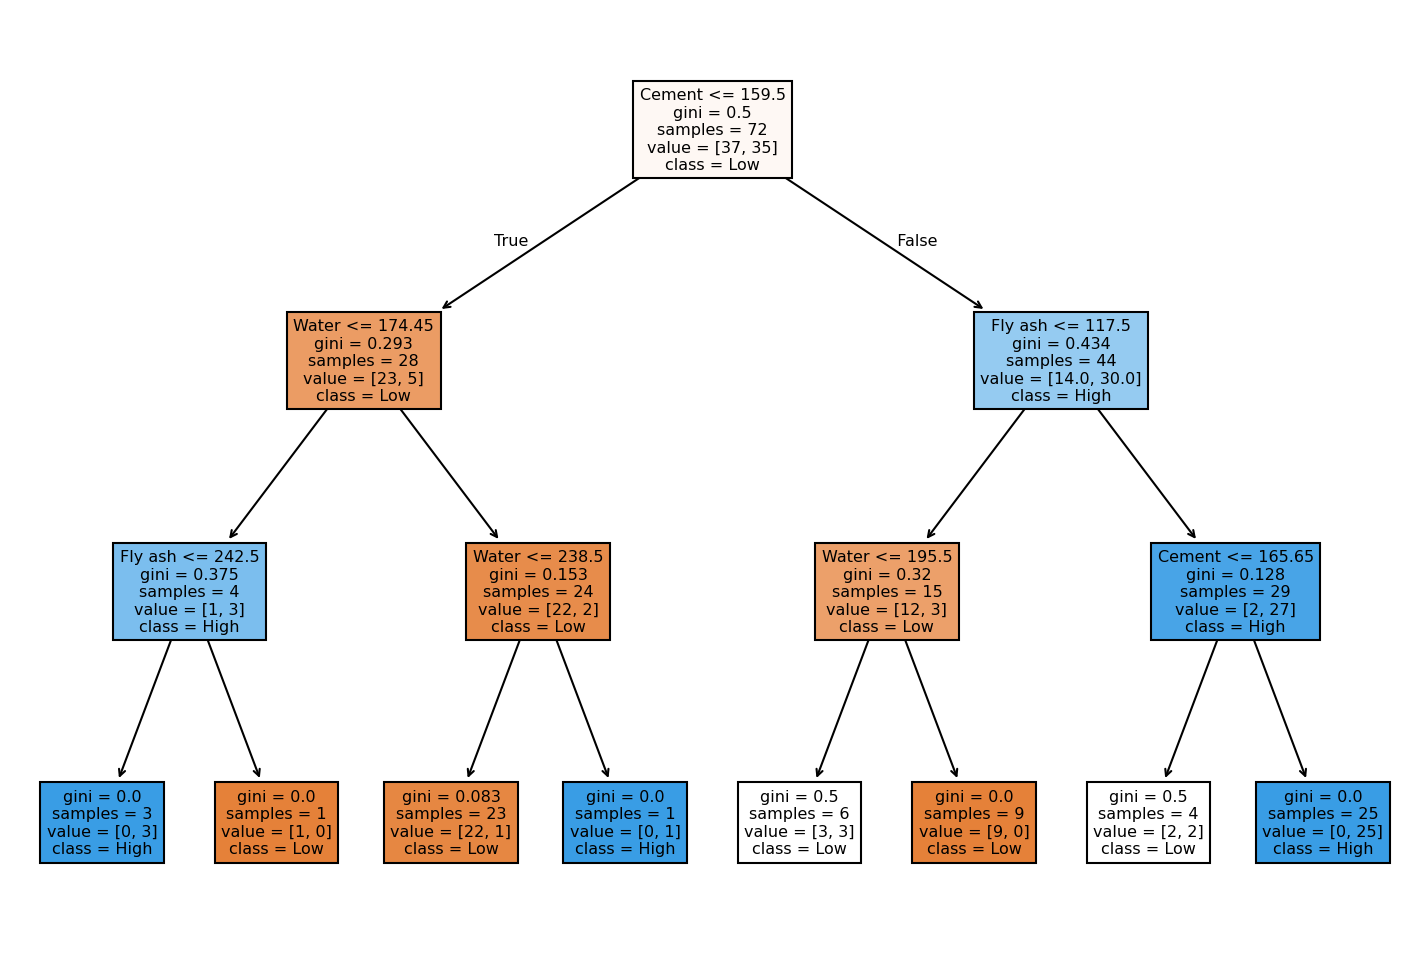

In [25]:
plt.figure(figsize=(12,8), dpi=150)
plot_tree(model, filled=True, feature_names=x.columns, class_names=['Low', 'High'])
plt.show()

In [ ]:
#"The tree shows that 'Cement' and 'Water' content are the primary factors in determining ifthe concrete will have high compressive strength."